

<div style="font-size: 0.6em; max-width: 70ch">

# Importing packages 

</div>

In [ ]:
# Use sys to add the path of the custome modules to the system path, so that 
# we can import them in this notebook.
import sys
# Import the path class to handle the directory paths
from pathlib import Path 
import pandas as pd
import numpy as np
# Import the os library to interact with the operating system
import os

# Import visualization tools
import matplotlib.pyplot as plt
from mplcursors import cursor
import seaborn as sns

# Import the important modules of plotly package
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff 

# Package for adding regression trendline in plotly graphs
import statsmodels 
import math
from scipy.stats import gaussian_kde

# To display the figure defined by this dict, use the low-level 
# plotly.io.show function
import plotly.io as pio
# Using "png" to display the figures as static images in the notebook.
pio.renderers.default = "png" 

# The following lines are required to avoid an error related to the 
# MutableMapping class in the collections module, which is used by the 
# FlowCytometryTools library. This error can occur in Python 3.10 and later 
# versions, where MutableMapping has been moved to the collections.abc module. 
# By adding this code, we ensure that MutableMapping is available in the 
# collections module, allowing FlowCytometryTools to function properly.
import collections
from collections.abc import MutableMapping
if not hasattr(collections, "MutableMapping"):
    collections.MutableMapping = MutableMapping

from FlowCytometryTools import FCMeasurement
import FlowCytometryTools as fct
from FlowCytometryTools import test_data_dir, test_data_file

# importing the custom modules of the project
import fcm_core.fcm as fcm

# Set the display options for pandas to show all columns and rows in the output.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<div style="font-size: 0.6em; max-width: 70ch">

# Load and clean the raw FCS data

</div>

In [ ]:
# keywords in the name of the file and the corresponding sample name
sample_name_map = {
    "Amino": "Aminoglutethimide", 
    "control": "DMSO",
} 

# keywords in the name of the file and the corresponding incubation duration 
incubation_map = {
    "16 h": "16 hours incubation", 
    "30 min": "30 minutes incubation"
} 

# The folder where the data is located. This location is used for loading and 
# saving the data. 
data_folder = "data/sample" 
df = fcm.compile_fcs_data(
    data_folder=data_folder, # Or change it to a specific folder of 
                             # data, e.g. "data/2026-05-29"
    sample_name_map= sample_name_map, 
    incubation_map=incubation_map, 
    # include_keywords=["Dig"], # The file name must contain this keyword. 
    # exclude_keywords=["DMSO"] 
)

Looking for data in: C:\Users\ardal\Desktop\notebooks for GitHub\fcm_graph_gen\data\sample

Processed files
------------------------------
File name: 29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs
File name: 29jul25 - Aminogluthetimide 2- pkh26 - 16 h.fcs
File name: 29jul25 - control positive 1- pkh26 - 16 h.fcs
File name: 29jul25 - control positive 2- pkh26 - 16 h.fcs
File name: 29jul25 - control positive 3- pkh26 - 16 h.fcs
File name: 9mar25 - control positive 1- pkh26 - 30 min.fcs
File name: 9mar25 - control positive 2- pkh26 - 30 min.fcs
File name: 9mar25 - control positive 3- pkh26 - 30 min.fcs
File name: 9mar25 Aminogluthetimide 1- pkh26 - 30 min.fcs
File name: 9mar25 Aminogluthetimide 2- pkh26 - 30 min.fcs
File name: 9mar25 Aminogluthetimide 3- pkh26 - 30 min.fcs

FCS COMPILATION SUMMARY
------------------------------
                                      File name            Sample  Count (Events)
29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs Aminoglutethimide            718

In [3]:
# change the number in head() to see more or less rows. For example, 
# use df.head(10) to see the first 10 rows of the dataframe.
df.head(10) 

,Sample,Incubation_duration,Date,File name,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,PKH67,Hoechst-A,BV510-A,PKH26,mCherry-A,YG-PE-CY5-A,APC-A,Alexa Fluor 700-A,Time
0,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,90634.046875,26180.0,226882.859375,65341.898438,21092.0,203027.062500,193.699997,329.509979,3448.649902,365.750000,40.849998,365.750000,322.420013,45.080002,52.200001
1,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,143083.968750,41257.0,227286.312500,64976.597656,19961.0,213331.328125,211.899994,317.889984,3624.609863,410.399994,58.899998,294.500000,299.880005,28.420000,52.299999
2,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,99886.406250,27514.0,237920.890625,66817.398438,20814.0,210384.593750,137.799988,209.159988,3017.879883,2098.550049,174.800003,872.099976,310.660004,52.920002,52.299999
3,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,89502.656250,31443.0,186548.546875,52553.796875,19383.0,177690.015625,101.399994,120.349998,2114.010010,246.050003,27.549999,203.300003,255.779999,67.620003,52.299999
4,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,104340.593750,29874.0,228896.875000,81510.000000,24630.0,216883.453125,122.199997,291.329987,3621.290039,666.899963,63.649998,466.449982,482.160004,48.020000,52.500000
5,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,117063.171875,33158.0,231372.593750,31540.599609,12614.0,163869.093750,223.599991,162.679993,3331.619873,501.600006,73.150002,730.549988,253.820007,60.760002,52.799999
6,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,71330.218750,24662.0,189550.625000,41663.699219,15942.0,171275.390625,72.799995,149.399994,1870.819946,9485.750000,854.049988,2820.550049,518.419983,243.040009,53.000000
7,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,109132.914062,37234.0,192086.140625,39143.000000,15010.0,170904.437500,115.699997,156.869995,1921.449951,342.000000,22.799999,140.599991,122.500000,53.900002,53.400002
8,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,64057.496094,24366.0,172292.218750,39930.796875,15898.0,164605.906250,114.399994,142.759995,2216.929932,395.199982,40.849998,216.599991,147.000000,108.779999,53.500000
9,Aminoglutethimide,16 hours incubation,29jul25,29jul25 - Aminogluthetimide 1- pkh26 - 16 h.fcs,78647.398438,24932.0,206731.750000,41502.500000,12704.0,214098.531250,156.000000,223.269989,2452.649902,168.149994,12.349999,369.549988,234.220001,49.000000,53.500000


<div style="font-size: 0.6em; max-width: 70ch">

# Data visualization

</div>




<div style="font-size: 0.6em; max-width: 70ch">

## Normalize the sample size

</div>

In [ ]:
# container for keeping the normalized slices of the dataframe. We will 
# concatenate these slices at the end to make a new dataframe with all the 
# normalized data.
normalized_dfs = [] 
# loop through the uniques dates in the dataframe and normalize the data
for date in df["Date"].unique(): 
    # select the slice of the dataframe for the current date
    exp_df = df.loc[df["Date"] == date] 
    df_normalize = fcm.sample_size_normalizer(
                        exp_df, # the slice of the dataframe for the current date
                        "Sample", # the name of the column that contains the 
                                  # sample names
                        30000, # the number of events to which we want to 
                               # normalize the data. 
                        "PKH26" # Choose the column related to the flow 
                                #cytometry channel cointaining the desired 
                                # marker (e.g. PKH26) 
                                
    )  
    normalized_dfs.append(df_normalize)

# Make a new df from all the normalized slices
df = pd.concat(normalized_dfs)

<div style="font-size: 0.6em; max-width: 70ch">

## Generate graphs

</div>

In [5]:
# See the overview of the average PKH26 signal samples for each experiment
# and incubation period.
df.pivot_table(index=["Sample", "Incubation_duration", "Date"], values="PKH26")

PKH26
Sample            Incubation_duration   Date                
Aminoglutethimide 16 hours incubation   29jul25   953.715515
                  30 minutes incubation 9mar25   6148.394043
DMSO              16 hours incubation   29jul25  1007.336487
                  30 minutes incubation 9mar25   5713.484863

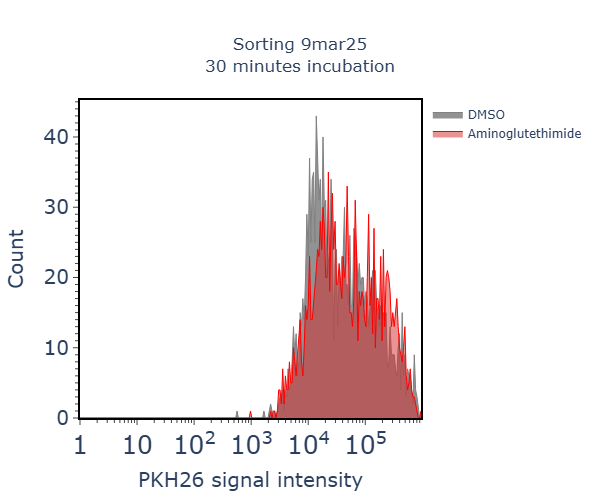

In [ ]:
# Generating graphs for the selected date, 9mar25.
graph = fcm.Graph(
    df, 
    samples=["DMSO", "Aminoglutethimide"], 
    incub_duration="30 minutes incubation", 
    channel="Size_normalized_PKH26",
    date="9mar25"
)

graph.set_layout(
                line_colors=["gray", "red"],
                fill_colors=["rgba(36, 37, 42, 0.5)", # blackish
                              "rgba(214, 39, 40, 0.5)"], # redish
                # Modify the tick values to the desired values or leave it
                # as None so that plotly automatically determines the
                # range.
                tick0=0, 
                dtick=10, 
                minor_dtick=1
)


save_fig=False # change to True if you want to save the figure.
save_path= r"YOUR/DESIRED/PATH/TO/SAVE/THE/FIGURE"  
graph.graph_generator(save_fig=save_fig, save_path=save_path)

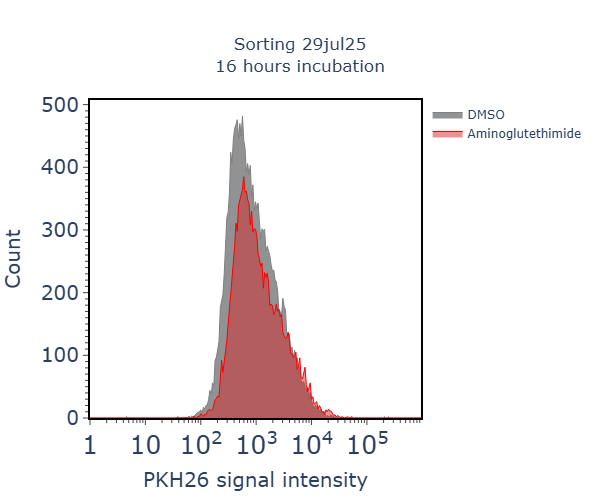

In [ ]:
# Generating graphs for the selected date, 29jul25.
graph = fcm.Graph(
    df, 
    samples=["DMSO", "Aminoglutethimide"], 
    incub_duration="16 hours incubation", 
    channel="Size_normalized_PKH26",
    date="29jul25"
)

graph.set_layout(
                line_colors=["gray", "red"],
                fill_colors=["rgba(36, 37, 42, 0.5)", # blackish
                              "rgba(214, 39, 40, 0.5)"], # redish
                # Modify the tick values to the desired values or leave it
                # as None so that plotly automatically determines the
                # range.
                tick0=None, 
                dtick=None, 
)


save_fig=False # change to True if you want to save the figure.
save_path= r"YOUR/DESIRED/PATH/TO/SAVE/THE/FIGURE"  
graph.graph_generator(save_fig=save_fig, save_path=save_path)

<div style="font-size: 0.6em; max-width: 70ch">

## Export the cleaned data

</div>

The graphs can be generated in excel or other software using this raw data.

In [ ]:
 # The path to the main folder of the data for saving the cleaned data. 
folders_path = Path(f"./../{data_folder}")
# export the dataframe to a csv file at the desired location. 
df.to_csv(folders_path / f"_{data_folder}_cleaned.csv") 